# Strong Coupling Expansion: Benchmarks on the dimer
Expansion around the atomic limit $t=0$ of various quantities the dimer

## Partition function and Thermodynamic potential

Exact partition function for the dimer and $\Omega = - \ln Z$ thermodynamic potential. 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from series import calculate_coeffs, partial_sum, estimate_radius
from plot_complex import complex_array_to_rgb
from hubbard_sc_exp import HubbardED
plt.rcParams['figure.dpi'] = 200

In [2]:
#exact atomic partition function
def Z_atomic(U:float,beta:float,mu:float):
    return 1+ 2*np.exp(beta*mu) + np.exp(-beta*(U-2*mu))



#exact dimer partition function
Eplus = lambda t,U: U/2 + np.sqrt(U**2/4 + 4*t**2)
Eminus = lambda t,U: U/2 - np.sqrt(U**2/4 + 4*t**2)
def Z(t:float,U:float,beta:float,mu:float):

    A = 1 + 2*np.exp(-beta*(-t-mu)) + 2*np.exp(-beta*(t-mu)) + 3*np.exp(2*beta*mu) + np.exp(-beta*(U-2*mu))
    B = np.exp(-beta*(Eplus(t,U)-2*mu)) + np.exp(-beta*(Eminus(t,U)-2*mu))
    C = 2*np.exp(-beta*(U+t-3*mu)) +2*np.exp(-beta*(U-t-3*mu)) + np.exp(-2*beta*U + 4 * beta * mu) 

    return A+B+C


#exact dimer thermodynamic potential
def logZ(t:float,U:float,beta:float,mu:float):
    return -1.0/2*np.log(Z(t,U,beta,mu)) #free energy per site

Plot of $Z(t)$ in the complex plane (left) and on the right the corresponding summed series for $-\ln Z$ truncated at finite order. 

In [3]:
#create a meshgrid of complex hopping values from -a to a. 
def get_tgrid(a:float, b:float, npoints:int):
    treal = np.linspace(a, b, npoints)
    tr, ti = np.meshgrid(treal, treal)
    return tr + 1j*ti

In [4]:
U = 6.0
beta = 3.0
mu = 2.0
r = 1.0 # radius for the complex plane plot
N = 500 # number of points in the circle of radius r to sample

a = -1.5
b = 1.5

#ln(Z(z))
z = np.linspace(0,b,100)
logpart = logZ(z,U,beta,mu)

#orders for plotting summation
orders = [4,6,8]
vals = []

for order in orders:
    logZapprox = partial_sum(z, N, logZ, order, r, U, beta, mu)
    vals.append(logZapprox)


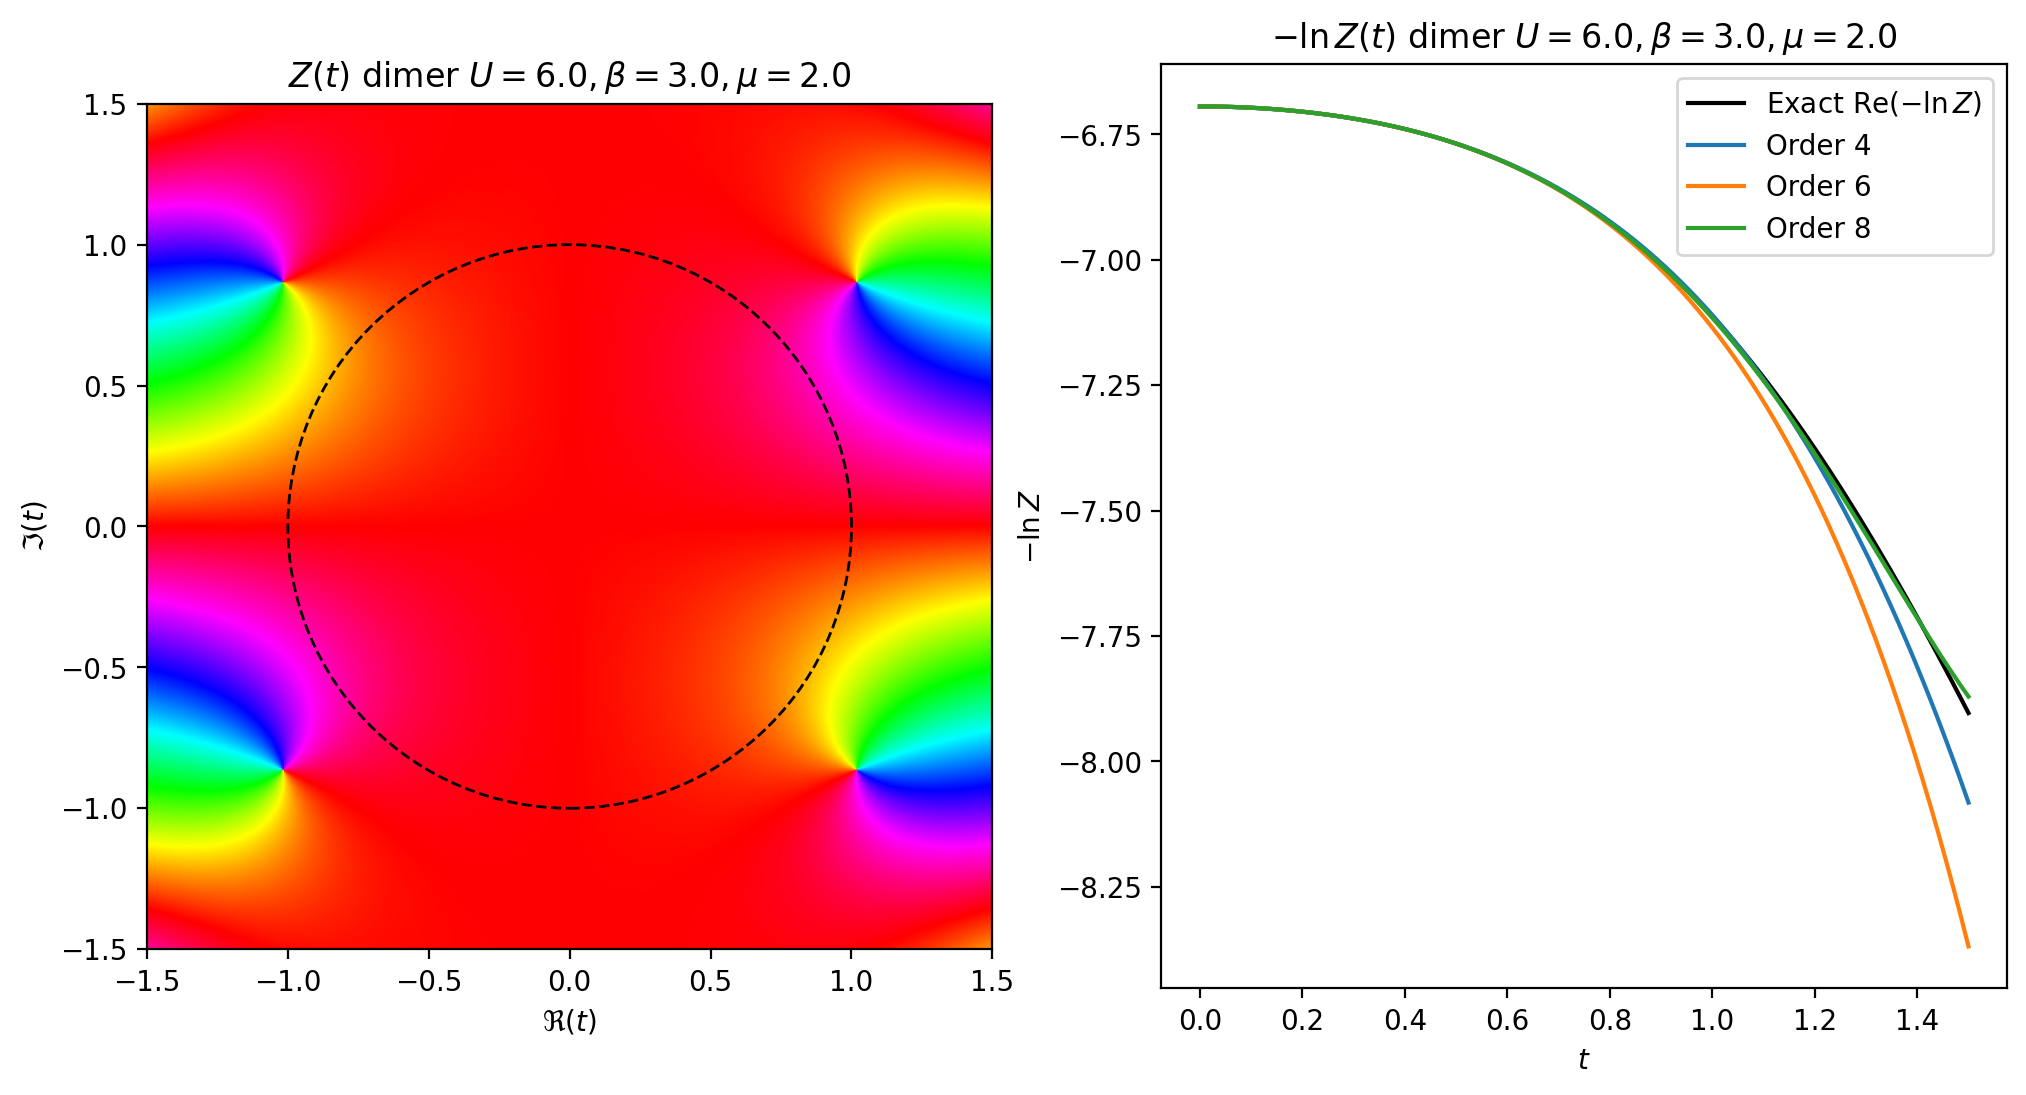

In [5]:
fig, (ax1, ax2)= plt.subplots(1,2, figsize=(12,6))

tgrid = get_tgrid(a,b, N)
Zgrid = Z(tgrid,U,beta,mu)

ax1.imshow(complex_array_to_rgb(Zgrid, rmax=4), extent=(a,b,a,b))
ax1.set_title(rf"$Z(t)$ dimer $U={U}, \beta={beta}, \mu={mu}$")
ax1.set_xlabel(r"$\Re(t)$")
ax1.set_ylabel(r"$\Im(t)$")

#rad = estimate_radius(f=lambda t: Z(t,U,beta,mu), max_order=10, r=r, N=N)
ax1.add_artist(plt.Circle((0,0), 1.0, color='black', fill=False, linestyle='dashed'))


ax2.plot(z, logpart.real, label=r"Exact Re($-\ln Z$)", color='black')

for i, order in enumerate(orders):
    ax2.plot(z, vals[i].real, label=rf"Order {order}")

ax2.set_title(rf"$-\ln Z(t)$ dimer $U={U}, \beta={beta}, \mu={mu}$")
ax2.set_xlabel(r"$t$")
ax2.set_ylabel(r"$-\ln Z$")
ax2.legend()

## Density $\langle \hat N \rangle$

In [6]:
def calculate_N_dimer(t,U, beta, mu, hub: HubbardED):


    neighbors_and_t = [(0,1,t)]

    top = 0.0
    bot = 0.0
    for sector in hub.basis:

        state = list(sector.keys())[0]
        N = bin(state).count('1')

        Ht = hub.Hamiltonian_Hopping(neighbors_and_t, sector)
        Hu, Hmu = hub.Hamiltonian_Diag(sector)

        H = Ht + U*Hu + mu*Hmu
        E = np.linalg.eigvals(H)
        top += N*np.sum(np.exp(-beta*E))
        bot += np.sum(np.exp(-beta*E))
        

    # if bot < 1e-10:
    #     return np.nan
    res = top / bot

    return res


def robust_complex_to_rgb(X, rmax=None):
    """Handle NaNs gracefully for domain coloring"""
    # Create a mask for NaNs (poles)
    mask = np.isnan(X) | np.isinf(X)
    X_safe = np.where(mask, 0, X) # Replace NaNs with 0 temp
    
    rgb = complex_array_to_rgb(X_safe, rmax=rmax)
    
    # Turn NaNs into pure white (or black) to make poles visible
    rgb[mask] = [1.0, 1.0, 1.0] 
    return rgb

In [24]:
hub = HubbardED(2)
mus = np.linspace(0,U,20)
t = 1.0
N_vect = np.vectorize(calculate_N_dimer, excluded=['hub'])


lnZmu = logZ(t,U,beta,mus)
Nmu_numerical = np.gradient(lnZmu, mus) * -1.0
Nmu_exact = N_vect(t, U, beta, mus, hub)

In [25]:
orders = [4,6] 
lnZmu_vals = []
for order in orders:
    temp = []
    for mu in mus:
        Napprox = partial_sum(t, N, logZ, order, r, U, beta, mu)
        temp.append(Napprox)
    lnZmu_vals.append(temp)
lnZmu_vals_series = np.array(lnZmu_vals)


/opt/anaconda3/envs/strong_coupling_conda/lib/python3.13/site-packages/matplotlib/cbook.py:1709: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/opt/anaconda3/envs/strong_coupling_conda/lib/python3.13/site-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


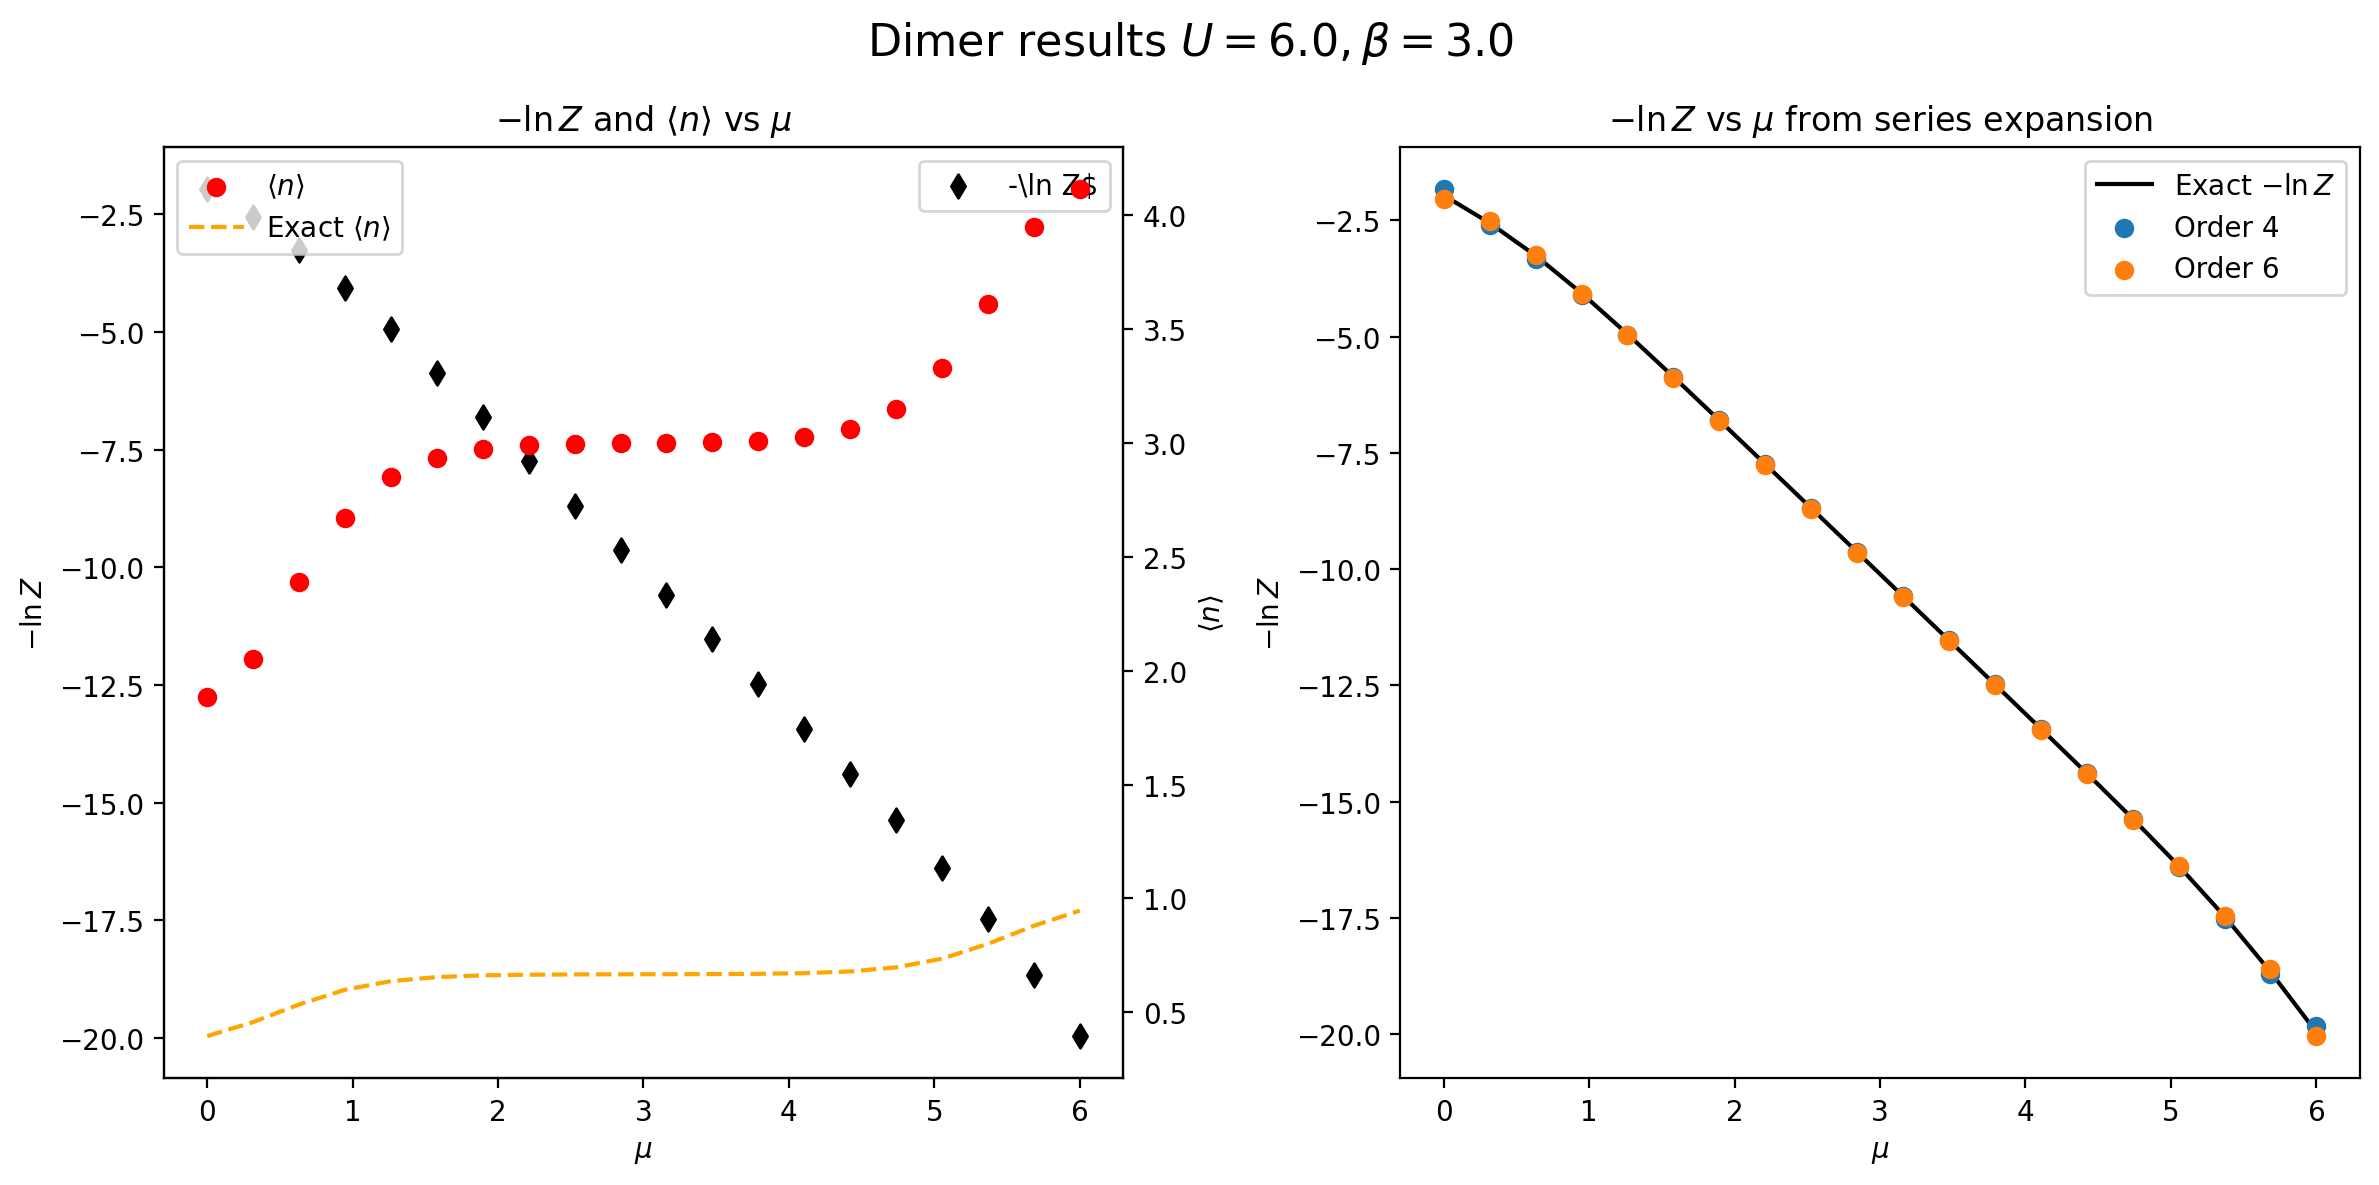

In [ ]:
fig, (ax1, ax2) = plt.subplots(1,2, figsize=(12,6))

fig.suptitle(rf"Dimer results $U={U}, \beta={beta}$", fontsize=16)

ax1.scatter(mus, lnZmu.real, label=r"-\ln Z$", marker='d', color='black')
ax1.set_xlabel(r"$\mu$")
ax1.set_ylabel(r"$-\ln Z$")

ax11 = ax1.twinx()
ax11.scatter(mus, Nmu_numerical, label =r"$\langle n \rangle$", color='red')
ax11.set_ylabel(r"$\langle n \rangle$")

ax11.plot(mus, Nmu_exact, label =r"Exact $\langle n \rangle$", color='orange', linestyle='dashed')

ax1.set_title(rf"$-\ln Z$ and $\langle n \rangle$ vs $\mu$")
ax1.legend()
ax11.legend()


ax2.plot(mus, lnZmu.real, label=r"Exact $-\ln Z$", color='black', zorder=1)
for i, order in enumerate(orders):
    ax2.scatter(mus, lnZmu_vals_series[i].real, label=rf"Order {order}")

ax2.set_xlabel(r"$\mu$")
ax2.set_ylabel(r"$-\ln Z$")
ax2.set_title(rf"$-\ln Z$ vs $\mu$ from series expansion")

ax2.legend()

plt.tight_layout()

In [ ]:
plt.plot(mus, Nmu.real)
for i, order in enumerate(orders):
    plt.scatter(mus, Nmu_vals[i].real, label=f"Order {order} Approximation")
plt.title(rf"Dimer Density $\langle \hat N \rangle$ at $t={t}, U={U}, \beta={beta}$")
plt.xlabel(r"$\mu$")
plt.ylabel(r"$\langle \hat N \rangle$")
plt.legend()

In [ ]:
plt.scatter(mus, Nmu.real)
plt.title(rf"Dimer Density $\langle \hat N \rangle$ at $t={t}, U={U}, \beta={beta}$")
plt.xlabel(r"$\mu$")
plt.ylabel(r"$\langle \hat N \rangle$")

In [ ]:
tgrid = get_tgrid(a,b, N)
mu = U/2.0
a = -1.5; b=1.5
N = 500

Ngrid = N_vect(tgrid, U, beta, mu, hub)

In [ ]:
orders = [4,6,8]
vals = []

for order in orders:
    Napprox = partial_sum(z, N, N_vect, order, r, U, beta, mu, hub)
    vals.append(Napprox)

ts = np.linspace(0,1.5,100)
Nexact = N_vect(ts, U, beta, mu, hub)

In [ ]:
fig, (ax1, ax2) = plt.subplots(1,2,figsize=(12,6))

ax1.imshow(robust_complex_to_rgb(Ngrid, rmax=2), extent=(a,b,a,b))
ax1.set_title(rf"Dimer Density $\langle \hat N \rangle$ at $U={U}, \beta={beta}, \mu={mu}$")
ax1.set_xlabel(r"$\Re(t)$")
ax1.set_ylabel(r"$\Im(t)$")



ax2.plot(ts, Nexact.real, label=r"Exact $\langle \hat N \rangle$", color='black')
for i, order in enumerate(orders):
    ax2.plot(z, vals[i].real, label=rf"Order {order}")

ax2.set_title(rf"Dimer Density $\langle \hat N \rangle$ at $U={U}, \beta={beta}, \mu={mu}$")
ax2.set_xlabel(r"$t$")
ax2.set_ylabel(r"$\langle \hat N \rangle$")
ax2.legend()


In [ ]:

a = calculate_coeffs(500, f = N_vect, max_order=12+1, r=1.0, U=U, beta=beta, mu=mu, hub=hub)
alnZ = calculate_coeffs(500, f = logZ, max_order=12+1, r=1.0, U=U, beta=beta, mu=mu)

In [ ]:
alnZ

In [ ]:
a

In [ ]:
haha = lambda t: a[0] + a[2]*t**2 + a[4]*t**4 + a[6]*t**6

In [ ]:
plt.plot(ts, haha(ts).real, label="Perturbation Theory", linestyle='dashed')
plt.plot(ts, Nexact.real, label=r"Exact $\langle \hat N \rangle$", color='black')

In [ ]:
Z_atomic(U, beta, mu)